In [46]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [47]:
df = pd.read_csv("data/cleaned_telco_churn.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,1,0,0,0
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,1,0,0,0,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,0,1,0,1,0


In [48]:
# split data into features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [52]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
y_train_resampled.value_counts()

Churn
0    4122
1    4122
Name: count, dtype: int64

In [53]:
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = { 
    "Logistic Regression": LogisticRegression(max_iter=1000), 
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss') 
    }

results = []

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)

    # For ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1, roc])

results_df = pd.DataFrame(
    results, 
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print(results_df)

C:\Users\anuga\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.787447   0.586288  0.668464  0.624685  0.830923
1        Random Forest  0.779601   0.582011  0.592992  0.587450  0.815823
2              XGBoost  0.766762   0.557592  0.574124  0.565737  0.809016


C:\Users\anuga\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [18:25:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [55]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grids
param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, class_weight='balanced'),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l2"],
            "solver": ["lbfgs"]
        }
    },
    
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4]
        }
    },
    
    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "subsample": [0.8, 1],
            "colsample_bytree": [0.8, 1]
        }
    }
}

# Store results
tuned_results = []

for name, mp in param_grids.items():
    print(f"\nTuning {name}...")

    search = RandomizedSearchCV(
        mp["model"],
        mp["params"],
        n_iter=10,
        cv=3,
        scoring="recall",  # important for churn
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train_resampled, y_train_resampled)

    best_model = search.best_estimator_

    # Predictions
    y_pred = best_model.predict(X_test)

    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    tuned_results.append([
        name,
        search.best_params_,
        acc,
        prec,
        rec,
        f1,
        roc
    ])

# Convert to DataFrame
tuned_df = pd.DataFrame(
    tuned_results,
    columns=["Model", "Best Params", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print(tuned_df)


Tuning Logistic Regression...


C:\Users\anuga\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\anuga\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\anuga\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to 


Tuning Random Forest...

Tuning XGBoost...
                 Model                                        Best Params  \
0  Logistic Regression    {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.01}   
1        Random Forest  {'n_estimators': 100, 'min_samples_split': 5, ...   
2              XGBoost  {'subsample': 0.8, 'n_estimators': 100, 'max_d...   

   Accuracy  Precision    Recall  F1 Score   ROC-AUC  
0  0.766762   0.547210  0.687332  0.609319  0.834981  
1  0.766049   0.542574  0.738544  0.625571  0.835149  
2  0.734665   0.499187  0.827493  0.622718  0.831296  


C:\Users\anuga\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [18:28:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [61]:
tuned_results

[['Logistic Regression',
  {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.01},
  0.7667617689015692,
  0.5472103004291845,
  0.6873315363881402,
  0.6093189964157706,
  0.8349808235795463],
 ['Random Forest',
  {'n_estimators': 100,
   'min_samples_split': 5,
   'min_samples_leaf': 1,
   'max_depth': 5},
  0.7660485021398002,
  0.5425742574257426,
  0.738544474393531,
  0.6255707762557078,
  0.8351494505896717],
 ['XGBoost',
  {'subsample': 0.8,
   'n_estimators': 100,
   'max_depth': 3,
   'learning_rate': 0.01,
   'colsample_bytree': 0.8},
  0.7346647646219686,
  0.4991869918699187,
  0.8274932614555256,
  0.6227180527383367,
  0.8312958658931612]]

In [62]:
final_model = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=1,
    max_depth=5,
    random_state=42
)

In [63]:
final_model.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [64]:
import pickle

# save model
with open("model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# save column names (VERY IMPORTANT for deployment)
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

## Trying Feature Selection

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances)

MonthlyCharges                           0.152519
TotalCharges                             0.142579
tenure                                   0.140513
Contract_Two year                        0.066380
TechSupport                              0.048168
Contract_One year                        0.046219
OnlineSecurity                           0.039692
Partner                                  0.038376
InternetService_Fiber optic              0.038116
InternetService_No                       0.033443
Dependents                               0.032649
PaymentMethod_Credit card (automatic)    0.027120
PaymentMethod_Mailed check               0.024987
OnlineBackup                             0.021918
gender                                   0.021599
DeviceProtection                         0.020382
PaperlessBilling                         0.018872
PaymentMethod_Electronic check           0.016559
MultipleLines                            0.015833
StreamingMovies                          0.015051


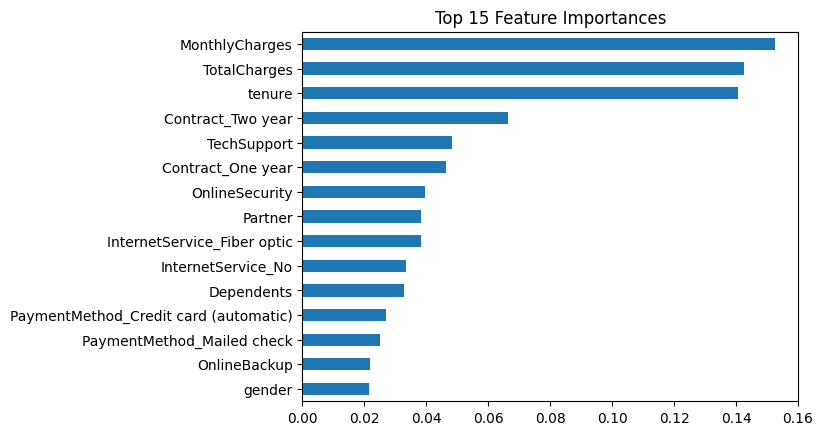

In [58]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [59]:
top_features = importances.head(15).index

X_train_sel = X_train_resampled[top_features]
X_test_sel = X_test[top_features]

In [60]:
results_fs = []

for name, model in models.items():
    model.fit(X_train_sel, y_train_resampled)
    y_pred = model.predict(X_test_sel)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_sel)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_fs.append([name, acc, prec, rec, f1, roc])

results_fs_df = pd.DataFrame(
    results_fs,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print(results_fs_df)

C:\Users\anuga\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.766762   0.546809  0.692722  0.611177  0.829091
1        Random Forest  0.771755   0.566580  0.584906  0.575597  0.817253
2              XGBoost  0.768902   0.555294  0.636119  0.592965  0.820790


C:\Users\anuga\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [18:35:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Decided not to use feature selection